In [5]:
import numpy as np
import librosa
import librosa.display
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import seaborn as sns

from mfcc import mfcc

In [ ]:
rate, signal = wav.read("example.wav")

signal = signal[:rate * 3]

features = mfcc(signal, rate)
print(features.shape)

/tmp/ipykernel_31188/3454405104.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wav.read("example.wav")


In [8]:
mfcc_custom = mfcc(signal, rate)

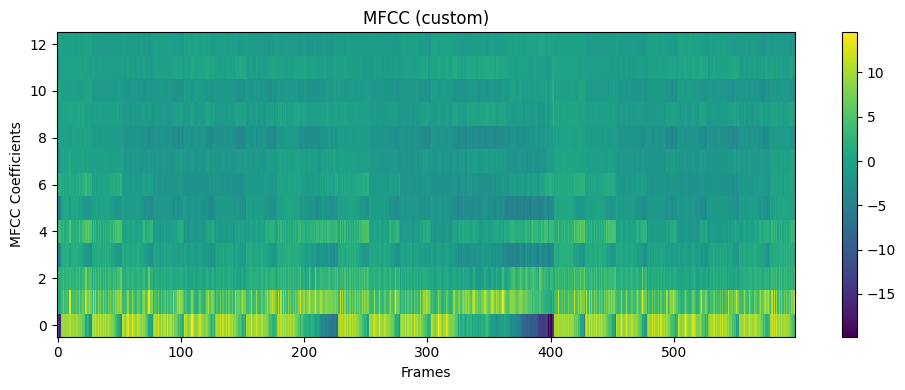

In [16]:
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_custom.T, interpolation="nearest", origin="lower", aspect="auto")
plt.title("MFCC (custom)")
plt.xlabel("Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.tight_layout()
plt.show()

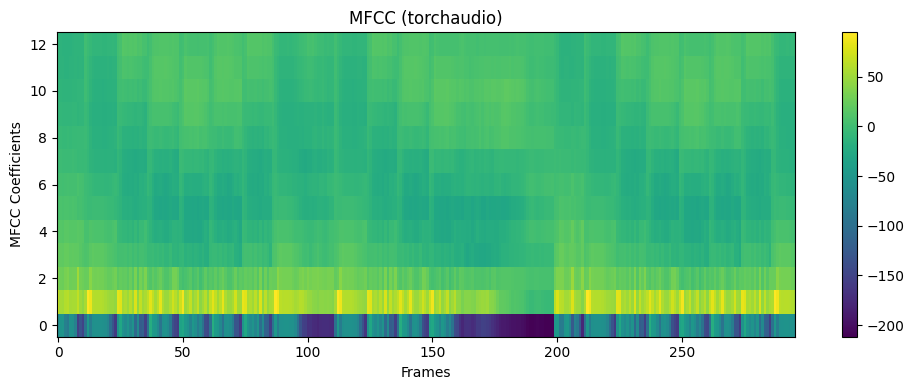

In [ ]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt

# === PARAMETRY ===
num_mfcc = 13
num_mels = 26
duration_sec = 3.0

# === WCZYTANIE SYGNAŁU (tylko pierwsze 3 sekundy) ===
audio, fs = torchaudio.load("example.wav")  # audio.shape = (channels, samples)
num_samples = int(duration_sec * fs)
audio = audio[:, :num_samples]

# === PARAMETRY CZASOWE ===
win_length = int(0.025 * fs)  # 25 ms
hop_length = int(0.010 * fs)  # 10 ms
n_fft = 2048  # większe niż win_length

# === TRANSFORMACJA MFCC ===
mfcc_transform = T.MFCC(
    sample_rate=fs,
    n_mfcc=num_mfcc,
    melkwargs={
        'n_fft': n_fft,
        'win_length': win_length,
        'hop_length': hop_length,
        'n_mels': num_mels,
        'window_fn': torch.hamming_window,
        'center': False
    }
)

# === OBLICZANIE MFCC ===
mfcc_torch = mfcc_transform(audio)  # shape: (1, num_mfcc, time)

# === WYKRES ===
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_torch[0].numpy(), interpolation="nearest", origin="lower", aspect="auto")
plt.title("MFCC (torchaudio)")
plt.xlabel("Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.tight_layout()
plt.show()
